In [2]:
from AGNopspecNN import *
import matplotlib.pyplot as plt
import seaborn as sns

## Training data
We use simulated data for training here.
The training data is in form of .json file with three rows: 
1. the first row: wavelength, We do not actually need this except for plotting
2. second row: flux, 
3. third row: spectral type labeled: 0,1 or 2. Here 0='Type-1', 1='Type-1.9', and 2='Type-2'

In [3]:
path_type1 = 'simulated_data/training/type-1/'
a1 = preprocess_1D_spectra(path_type1)
a1.preprocess_data("cnn")
X_train1, y_train1 = a1.X, a1.y

path_type1pt9 = 'simulated_data/training/type-1.9/'
a2 = preprocess_1D_spectra(path_type1pt9)
a2.preprocess_data("cnn")
X_train2, y_train2 = a2.X, a2.y

path_type2 = 'simulated_data/training/type-2/' 
a3 = preprocess_1D_spectra(path_type2)
a3.preprocess_data("cnn")
X_train3, y_train3 = a3.X, a3.y

In [4]:
X_train = np.concatenate((X_train1, X_train2, X_train3), axis=0)
y_train = np.concatenate((y_train1, y_train2, y_train3))

## Test data

In [5]:
path_type1 = 'simulated_data/test/type-1/'
a1 = preprocess_1D_spectra(path_type1)
a1.preprocess_data("cnn")
X_test1, y_test1 = a1.X, a1.y

path_type1pt9 = 'simulated_data/test/type-1.9/'
a2 = preprocess_1D_spectra(path_type1pt9)
a2.preprocess_data("cnn")
X_test2, y_test2 = a2.X, a2.y

path_type2 = 'simulated_data/test/type-2/' 
a3 = preprocess_1D_spectra(path_type2)
a3.preprocess_data("cnn")
X_test3, y_test3 = a3.X, a3.y

In [6]:
X_test = np.concatenate((X_test1, X_test2, X_test3), axis=0)
y_test = np.concatenate((y_test1, y_test2, y_test3))

## Load the neural network class 

In [7]:
n1 = convagnNN()

n1.X_train = X_train
n1.y_train = y_train

n1.X_test = X_test
n1.y_test = y_test

n1.epochs = 100
n1.input_dim = n1.X_train.shape[1:3]

In [10]:
n1.model_compile()
n1.train(verbose=1)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6572 - loss: 0.6926
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9014 - loss: 0.2973
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9225 - loss: 0.2346
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9301 - loss: 0.1942
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9543 - loss: 0.1219
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9681 - loss: 0.0924
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9687 - loss: 0.0848
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9731 - loss: 0.0794
Epoch 9/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9726 - loss: 0.0765
Epoch 10/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9768 - loss: 0.0621
Epoch 11/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9777 - loss: 0.0639
Epoch 12/100
469/469 ━━━━━━━━━━━━━━━━━━━━

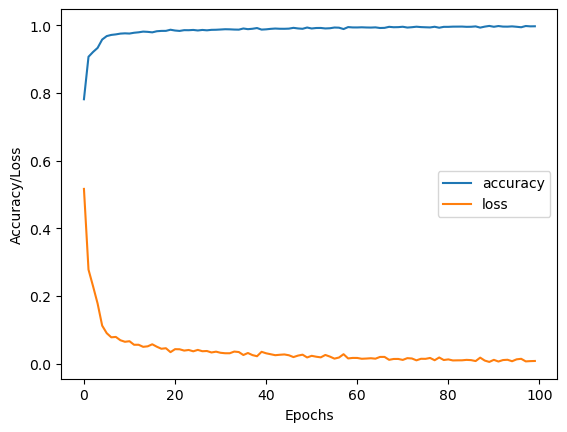

In [11]:
n1.performance()

In [12]:
n1.model.evaluate(X_test, y_test)
n1.tests()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9809 - loss: 0.0493      
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98       100
         1.0       0.96      0.99      0.98       100
         2.0       0.99      0.99      0.99       100

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



Text(45.722222222222214, 0.5, 'Truth')

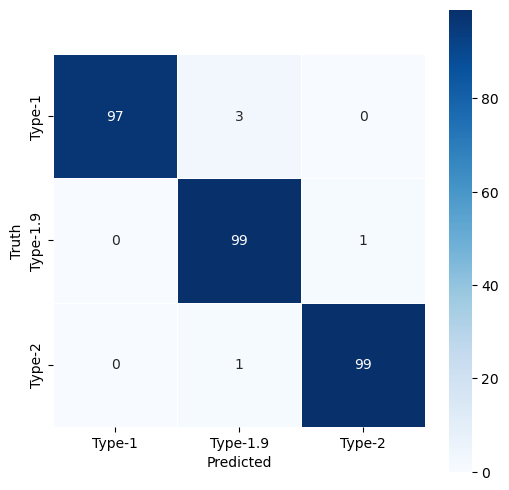

In [13]:
labels = ['Type-1', 'Type-1.9', 'Type-2']

plt.figure(figsize=(6,6))
sns.heatmap(n1.cm, annot=True, fmt='d', linewidths=.5, square = True, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [14]:
n1.model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 481, 4)         │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 120, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 117, 2)         │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 29, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 58)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,661 (76.80 KB)

 Trainable params: 6,553 (25.60 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,108 (51.21 KB)

## Test for 1 random spectrum

For classifying any random spectrum one needs to interpolate it such tath it has 500 bins, this is what the neural network accepts.

In [15]:
x1 = np.loadtxt("simulated_data/test_classify_spectrum/spec1.txt", usecols=(0,))
y1 = np.loadtxt("simulated_data/test_classify_spectrum/spec1.txt", usecols=(1,))

x2 = np.loadtxt("simulated_data/test_classify_spectrum/spec2.txt", usecols=(0,))
y2 = np.loadtxt("simulated_data/test_classify_spectrum/spec2.txt", usecols=(1,))

x3 = np.loadtxt("simulated_data/test_classify_spectrum/spec3.txt", usecols=(0,))
y3 = np.loadtxt("simulated_data/test_classify_spectrum/spec3.txt", usecols=(1,))


test1 = preprocess_1D_spectra(None)

x1,y1 = test1.standardize_the_dataset(x1,y1)
x2,y2 = test1.standardize_the_dataset(x2,y2)
x3,y3 = test1.standardize_the_dataset(x3,y3)

In [16]:
n1.classify_the_spectrum(y3)

Type 2 AGN


2

#### Save the trained model with: model_save(path) 

In [ ]:
#n1.model_save('trained_model')